# Direct Pekeris Helium Solver

This notebook implements the 1958 Pekeris ground-state helium method directly from Eq. (22) in the paper.

The approach follows a clean chain of steps:
1. Build a symmetry-reduced polynomial basis in the perimetric coordinates $(u, v, w)$, truncated at order $\omega$.
2. For each basis state $(l, m, n)$, encode Pekeris' 33-term recurrence relation as a row of the determinant matrix.
3. Split the matrix into a constant part $\mathbf{a}$ and an $\epsilon$-linear part $\mathbf{b}$, giving the generalised eigenvalue problem $(-\mathbf{a})\mathbf{x} = \epsilon\,\mathbf{b}\mathbf{x}$.
4. Solve for the largest positive real eigenvalue $\epsilon$, then recover the ground-state energy via $E = -\epsilon^2$.

Each cell below corresponds to one step in this chain.

## Imports

The implementation uses only the scientific Python stack:
- `numpy` for dense matrix storage and eigenvalue filtering,
- `scipy.linalg.eig` for the generalised eigenvalue problem,
- `matplotlib` for the convergence plot.

In [1]:
from dataclasses import dataclass
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

## Result container

A frozen dataclass keeps all outputs and metadata in one place. Using named fields rather than a plain tuple means that when we benchmark over many values of $\omega$, each result carries everything needed to build the convergence table without any index arithmetic.

In [2]:
@dataclass(frozen=True)
class SolveResult:
    omega: int
    basis_size: int
    epsilon: float
    energy_hartree: float
    build_seconds: float
    solve_seconds: float
    total_seconds: float
    nuclear_charge: int

## Building the symmetry-reduced basis

### Why `l <= m`?

For the $1^1S$ helium ground state the wavefunction is symmetric under electron exchange, which means the expansion coefficients satisfy
$$A(l,m,n) = A(m,l,n).$$
We therefore keep only states where $l \le m$. Storing both $(l,m,n)$ and $(m,l,n)$ for $l \ne m$ would double-count those contributions.

### The loop structure

The triple loop parameterises all non-negative integer triples $(l, m, n)$ with $l + m + n \le \omega$ using auxiliary variables:
- `ww` $= l+m+n$ (total polynomial degree),
- `vv` $= l+m$,
- so $l = $ `uu`, $m = $ `vv - uu`, $n = $ `ww - vv`.

This ordering reproduces Pekeris' Table I exactly.

### Folding shifted states back into canonical form

When Eq. (22) shifts a state $(l, m, n)$ by $(\Delta l, \Delta m, \Delta n)$, the result may have $l' > m'$. The singlet symmetry $A(l', m', n') = A(m', l', n')$ means we just swap the first two indices to map it back into the $l \le m$ half. `canonical_singlet_state` does exactly this.

In [3]:
def symmetric_basis_for_omega(omega: int) -> list[tuple[int, int, int]]:
    """Return the ordered list of (l, m, n) triples with l <= m and l+m+n <= omega.

    The ordering follows Pekeris' Table I for the symmetrical (singlet) case.
    """
    basis: list[tuple[int, int, int]] = []
    for ww in range(omega + 1):
        for vv in range(ww + 1):
            for uu in range(vv + 1):
                l = uu
                m = vv - uu
                n = ww - vv
                if l + m + n <= omega and l <= m:
                    basis.append((l, m, n))
    return basis


def canonical_singlet_state(l: int, m: int, n: int) -> tuple[int, int, int]:
    """Return (l, m, n) in canonical l <= m form, swapping l and m if necessary.

    Uses the singlet symmetry A(l, m, n) = A(m, l, n) to fold shifted states
    back into the half of the basis that was retained.
    """
    return (l, m, n) if l <= m else (m, l, n)


# Quick sanity check: show the basis for omega = 3
basis_3 = symmetric_basis_for_omega(3)
print(f"omega=3: {len(basis_3)} states")
for i, state in enumerate(basis_3):
    print(f"  {i:2d}  {state}  sum={sum(state)}")

omega=3: 13 states
   0  (0, 0, 0)  sum=0
   1  (0, 0, 1)  sum=1
   2  (0, 1, 0)  sum=1
   3  (0, 0, 2)  sum=2
   4  (0, 1, 1)  sum=2
   5  (0, 2, 0)  sum=2
   6  (1, 1, 0)  sum=2
   7  (0, 0, 3)  sum=3
   8  (0, 1, 2)  sum=3
   9  (0, 2, 1)  sum=3
  10  (1, 1, 1)  sum=3
  11  (0, 3, 0)  sum=3
  12  (1, 2, 0)  sum=3


## Encoding Eq. (22) — the 33-term recurrence

This is the algebraic heart of the implementation.

For each basis state $(l, m, n)$, Pekeris' Eq. (22) gives a linear combination of 33 shifted expansion coefficients:
$$\sum_{\alpha,\beta,\gamma} C_{\alpha\beta\gamma}(l,m,n)\, A(l+\alpha, m+\beta, n+\gamma) = 0.$$

Each coefficient splits into a part independent of $\epsilon$ and a part linear in $\epsilon$:
$$C_{\alpha\beta\gamma}(l,m,n) = a_{\alpha\beta\gamma}(l,m,n) + \epsilon \cdot b_{\alpha\beta\gamma}(l,m,n).$$

The function below returns all 33 entries as `(shift, a, b)` triples. The 33 terms are grouped by which Laguerre identity produced them:

| Group | Shifts | Origin |
|:------|:-------|:-------|
| +2 shifts | $(2,0,0)$, $(0,2,0)$, $(1,1,0)$, $(1,0,1)$, $(0,1,1)$, $(0,0,2)$ | $xL_n''$ identity |
| +1 shifts | $(1,0,0)$, $(0,1,0)$, $(0,0,1)$ | $xL_n'$ identity |
| mixed +2/−1 | $(0,2,{-1})$, $(2,0,{-1})$, $({-1},0,2)$, $(0,{-1},2)$ | cross-derivative PDE terms |
| diagonal | $(0,0,0)$ | middle-index contributions from all $xL_n$ identities |
| mixed +1/−1 | $({-1},1,0)$, $(1,{-1},0)$, $({-1},0,1)$, $(0,{-1},1)$, $(1,0,{-1})$, $(0,1,{-1})$ | off-diagonal cross-derivative terms |
| −1 shifts | $({-1},0,0)$, $(0,{-1},0)$, $(0,0,{-1})$ | $xL_n'$ lowering side |
| ±2 shifts | $(1,0,{-2})$, $(0,1,{-2})$, $({-2},0,1)$, $(0,{-2},1)$, $({-2},0,0)$, $(0,{-2},0)$, $(0,0,{-2})$ | $L_n''$ lowering |
| double −1 | $({-1},{-1},0)$, $({-1},0,{-1})$, $(0,{-1},{-1})$ | coupling to doubly lower-order coefficients |

**Key observations:**
- When `a = 0`: the shift comes purely from the $xL_n$ coordinate-multiplication identity and carries no Coulomb or kinetic factor, so it only contributes to $\mathbf{b}$.
- When `b = 0`: the shift comes from the pure $L_n''$ second-derivative identity on $w$, which introduces no coordinate factor. The $(0,0,\pm2)$ terms fall into this category.
- The diagonal term `(0,0,0)` is the most algebraically complex because it collects the "middle index" part from every $xL_n$ identity simultaneously.
- Many prefactors naturally vanish at the basis boundary — e.g., $4l(l-1)z$ for shift $(-2,0,0)$ is zero when $l=0$ or $l=1$, so those terms contribute nothing before the bounds check even fires.

In [4]:
def eq22_terms(
    l: int, m: int, n: int, z: int
) -> list[tuple[tuple[int, int, int], float, float]]:
    """Return the 33 terms of Pekeris' Eq. (22) as (shift, a, b) triples.

    Each triple means: coefficient A(l+dl, m+dm, n+dn) is multiplied by
    (a + epsilon * b) in the recurrence equation for A(l, m, n).

    Parameters
    ----------
    l, m, n : int
        Indices of the current basis state.
    z : int
        Nuclear charge (Z=2 for helium).

    Returns
    -------
    list of ((dl, dm, dn), a, b)
        The 33 recurrence terms, grouped by their origin in the Laguerre identities.
    """
    terms: list[tuple[tuple[int, int, int], float, float]] = []

    def add(shift: tuple[int, int, int], a: float, b: float) -> None:
        terms.append((shift, float(a), float(b)))

    # +2 shifts: from the xL_n''(x) identity on u, v, and their cross terms
    add((2, 0, 0), -4 * (l + 1) * (l + 2) * z, 4 * (l + 1) * (l + 2) * (1 + m + n))
    add((0, 2, 0), -4 * (m + 1) * (m + 2) * z, 4 * (m + 1) * (m + 2) * (1 + l + n))
    add((1, 1, 0), 4 * (l + 1) * (m + 1) * (1 - 2 * z), 4 * (l + 1) * (m + 1) * (2 + l + m))
    add((1, 0, 1), 2 * (l + 1) * (n + 1) * (1 - 2 * z), 2 * (l + 1) * (n + 1) * (2 + 2 * m + n))
    add((0, 1, 1), 2 * (m + 1) * (n + 1) * (1 - 2 * z), 2 * (m + 1) * (n + 1) * (2 + 2 * l + n))
    add((0, 0, 2), (n + 1) * (n + 2), 0)

    # +1 shifts: from the xL_n'(x) identity
    add(
        (1, 0, 0),
        (l + 1) * (4 * z * (4 * l + 4 * m + 2 * n + 7) - 8 * m - 4 * n - 6),
        -2 * (l + 1) * ((m + n) * (4 * m + 12 * l) + n**2 + 12 * l + 18 * m + 15 * n + 14),
    )
    add(
        (0, 1, 0),
        (m + 1) * (4 * z * (4 * l + 4 * m + 2 * n + 7) - 8 * l - 4 * n - 6),
        -2 * (m + 1) * ((l + n) * (4 * l + 12 * m) + n**2 + 12 * m + 18 * l + 15 * n + 14),
    )
    add(
        (0, 0, 1),
        4 * (n + 1) * (z * (2 * l + 2 * m + 2) - l - m - n - 2),
        4 * (n + 1) * (l**2 + m**2 - 4 * l * m - 2 * l * n - 2 * m * n - 3 * l - 3 * m - 2 * n - 2),
    )

    # mixed +2/-1 shifts: from cross-derivative terms in the perimetric PDE
    add((0, 2, -1), 0, 4 * (m + 1) * (m + 2) * n)
    add((2, 0, -1), 0, 4 * (l + 1) * (l + 2) * n)
    add((-1, 0, 2), 0, 2 * l * (n + 1) * (n + 2))
    add((0, -1, 2), 0, 2 * m * (n + 1) * (n + 2))

    # diagonal (0,0,0): collects all middle-index contributions from every xL_n identity
    add(
        (0, 0, 0),
        4 * (2 * l + 1) * (2 * m + 1)
        + 4 * (2 * n + 1) * (l + m + 1)
        + 6 * n**2
        + 6 * n
        + 2
        - 4 * z * ((l + m) * (6 * l + 6 * m + 4 * n + 12) - 4 * l * m + 4 * n + 8),
        4
        * (
            (l + m) * (10 * l * m + 10 * m * n + 10 * l * n + 10 * l + 10 * m + 18 * n + 4 * n**2 + 16)
            + l * m * (4 - 12 * n)
            + 8
            + 12 * n
            + 4 * n**2
        ),
    )

    # mixed +1/-1 shifts: off-diagonal parts of the cross-derivative PDE terms
    add((-1, 1, 0), 4 * l * (m + 1) * (1 - 2 * z), 4 * l * (m + 1) * (1 + l + m))
    add((1, -1, 0), 4 * (l + 1) * m * (1 - 2 * z), 4 * (l + 1) * m * (1 + l + m))
    add((-1, 0, 1), 2 * l * (n + 1) * (1 - 2 * z), 2 * l * (n + 1) * (2 * m - 4 * l - n))
    add((0, -1, 1), 2 * m * (n + 1) * (1 - 2 * z), 2 * m * (n + 1) * (2 * l - 4 * m - n))
    add((1, 0, -1), 2 * (l + 1) * n * (1 - 2 * z), 2 * (l + 1) * n * (2 * m - 4 * l - n - 3))
    add((0, 1, -1), 2 * (m + 1) * n * (1 - 2 * z), 2 * (m + 1) * n * (2 * l - 4 * m - n - 3))

    # -1 shifts: lowering terms from the xL_n'(x) identity
    add(
        (-1, 0, 0),
        2 * l * (-(4 * m + 2 * n + 3) + z * (8 * l + 8 * m + 4 * n + 6)),
        -2 * l * ((m + n + 1) * (12 * l + 4 * m + 2) + n + n**2),
    )
    add(
        (0, -1, 0),
        2 * m * (-(4 * l + 2 * n + 3) + z * (8 * l + 8 * m + 4 * n + 6)),
        -2 * m * ((l + n + 1) * (12 * m + 4 * l + 2) + n + n**2),
    )
    add(
        (0, 0, -1),
        4 * n * (-(l + m + n + 1) + z * (2 * l + 2 * m + 2)),
        -4 * n * ((l + m) * (1 + 2 * n - l - m) + 6 * l * m + 2 * n),
    )

    # ±2 shifts: from L_n''(x) lowering and mixed cross terms
    add((1, 0, -2), 0, 2 * n * (n - 1) * (l + 1))
    add((0, 1, -2), 0, 2 * n * (n - 1) * (m + 1))
    add((-2, 0, 1), 0, 4 * l * (l - 1) * (n + 1))
    add((0, -2, 1), 0, 4 * m * (m - 1) * (n + 1))
    add((-2, 0, 0), -4 * l * (l - 1) * z, 4 * l * (l - 1) * (1 + m + n))
    add((0, -2, 0), -4 * m * (m - 1) * z, 4 * m * (m - 1) * (1 + l + n))
    add((0, 0, -2), n * (n - 1), 0)

    # double -1 shifts: coupling to coefficients lower in two indices simultaneously
    add((-1, -1, 0), 4 * l * m * (1 - 2 * z), 4 * l * m * (l + m))
    add((-1, 0, -1), 2 * l * n * (1 - 2 * z), 2 * l * n * (2 * m + n + 1))
    add((0, -1, -1), 2 * m * n * (1 - 2 * z), 2 * m * n * (2 * l + n + 1))

    return terms


# Verify: the function always returns exactly 33 terms
assert len(eq22_terms(2, 3, 1, 2)) == 33
print("eq22_terms returns 33 terms: OK")

eq22_terms returns 33 terms: OK


## Assembling the two matrices

Row $j$ of the matrix corresponds to writing Eq. (22) for basis state $j$. Each of the 33 shifts nominates a target column. Three filters decide whether to accept it:

1. **Non-negativity**: if any shifted index goes negative, the state is outside the basis. Skip it.
2. **Truncation boundary**: if $l' + m' + n' > \omega$, the state is beyond our finite subspace. Skip it — this is the approximation that converges as $\omega$ increases.
3. **Canonical lookup**: after folding with `canonical_singlet_state`, look up the column. If the result is not in the basis (can happen at the boundary), skip it.

The `+=` accumulation is essential because multiple different shifts can target the same column. Their contributions must be summed into the same matrix entry.

After the loop:
- $\mathbf{a}$ holds all constant-in-$\epsilon$ coefficients.
- $\mathbf{b}$ holds all $\epsilon$-proportional coefficients.

In [5]:
def build_paper_matrices(
    omega: int, z: int = 2
) -> tuple[np.ndarray, np.ndarray, list[tuple[int, int, int]]]:
    """Build the a and b matrices from Pekeris' Eq. (22).

    The full coefficient matrix is a + epsilon * b.
    The energy is recovered from the generalised eigenvalue problem (-a)x = epsilon*b*x.

    Parameters
    ----------
    omega : int
        Polynomial truncation order. Larger omega gives a larger basis and higher accuracy.
    z : int
        Nuclear charge. Use z=2 for helium, z=1 for hydrogen-like ions.

    Returns
    -------
    a, b : ndarray of shape (N, N)
        Constant and epsilon-linear parts of the coefficient matrix.
    basis : list of (l, m, n)
        Ordered list of basis states corresponding to rows/columns.
    """
    basis = symmetric_basis_for_omega(omega)
    index = {state: i for i, state in enumerate(basis)}
    size = len(basis)
    a = np.zeros((size, size), dtype=np.float64)
    b = np.zeros((size, size), dtype=np.float64)

    for row, (l, m, n) in enumerate(basis):
        for (dl, dm, dn), const_part, linear_part in eq22_terms(l, m, n, z):
            lp = l + dl
            mp = m + dm
            np_ = n + dn

            # Skip states with negative indices
            if lp < 0 or mp < 0 or np_ < 0:
                continue
            # Skip states beyond the truncation boundary
            if lp + mp + np_ > omega:
                continue

            # Fold back into l <= m canonical form, then look up the column
            state = canonical_singlet_state(lp, mp, np_)
            col = index.get(state)
            if col is None:
                continue

            # Multiple shifts can target the same column: accumulate
            a[row, col] += const_part
            b[row, col] += linear_part

    return a, b, basis

## Solving for $\epsilon$ and the energy

The determinant condition $\det(\mathbf{a} + \epsilon\,\mathbf{b}) = 0$ is equivalent to the generalised eigenvalue problem:
$$(-\mathbf{a})\mathbf{x} = \epsilon\,\mathbf{b}\mathbf{x}.$$

The sign flip on $\mathbf{a}$ puts the problem into the standard form expected by SciPy, where the physical $\epsilon$ appears as a positive real eigenvalue.

### Filtering the eigenvalues

The generalised eigenvalue solver returns a full spectrum, most of which is non-physical:

| Filter | What it removes | Why it appears |
|:-------|:---------------|:---------------|
| `np.isfinite` | `inf` and `nan` | Near-singular $\mathbf{b}$ at small $\omega$ |
| `imag < 1e-9` | Complex eigenvalues | Truncated matrices are not exactly symmetric |
| `real > 0` | Negative eigenvalues | Different spectral branch, not bound states |

The **largest** positive real eigenvalue is the ground-state $\epsilon$. Smaller positive eigenvalues correspond to excited states.

Once $\epsilon$ is known:
$$E = -\epsilon^2 \quad (\text{in hartree}).$$

In [6]:
def solve_paper_determinant(omega: int, z: int = 2) -> SolveResult:
    """Solve for the helium ground-state energy at polynomial order omega.

    Builds the Pekeris a and b matrices, solves the generalised eigenvalue problem
    (-a)x = epsilon*b*x, and returns the energy E = -epsilon^2.
    """
    build_start = time.perf_counter()
    a, b, basis = build_paper_matrices(omega, z=z)
    build_seconds = time.perf_counter() - build_start

    solve_start = time.perf_counter()
    eigenvalues = eig(-a, b, left=False, right=False, check_finite=False)
    solve_seconds = time.perf_counter() - solve_start

    # Filter to finite, real, positive eigenvalues
    finite = eigenvalues[np.isfinite(eigenvalues)]
    real = finite[np.abs(finite.imag) < 1.0e-9].real
    positive = real[real > 0]
    if positive.size == 0:
        raise RuntimeError(f"No positive real epsilon found for omega={omega}.")

    epsilon = float(np.max(positive))
    energy_hartree = -(epsilon**2)

    return SolveResult(
        omega=omega,
        basis_size=len(basis),
        epsilon=epsilon,
        energy_hartree=energy_hartree,
        build_seconds=build_seconds,
        solve_seconds=solve_seconds,
        total_seconds=build_seconds + solve_seconds,
        nuclear_charge=z,
    )


def benchmark(omegas: list[int], z: int = 2) -> list[SolveResult]:
    """Run solve_paper_determinant for each omega and return all results."""
    return [solve_paper_determinant(omega, z=z) for omega in omegas]


def print_results(results: list[SolveResult]) -> None:
    """Print a formatted convergence table."""
    print(" omega  size    epsilon        energy / Ha        build / s   solve / s   total / s")
    for r in results:
        print(
            f"{r.omega:>6d} {r.basis_size:>5d} "
            f"{r.epsilon:>12.9f} {r.energy_hartree:>16.12f} "
            f"{r.build_seconds:>10.4f} {r.solve_seconds:>10.4f} "
            f"{r.total_seconds:>10.4f}"
        )

## Single calculation at $\omega = 10$

The $\omega = 10$ basis has 161 states. The exact non-relativistic helium ground-state energy is approximately $-2.903724377\,E_\mathrm{h}$. We expect to be correct to about 6 decimal places at this truncation.

In [7]:
omega = 10
result = solve_paper_determinant(omega)
print_results([result])

 omega  size    epsilon        energy / Ha        build / s   solve / s   total / s
    10   161  1.704031722  -2.903724111149     0.0034     0.0178     0.0211


## Convergence with $\omega$

One of the most transparent features of the Pekeris method is how visibly the energy converges as the basis grows. Each row below adds more basis functions and the energy settles monotonically toward the exact value.

The basis size for the symmetric case grows as approximately $\omega^3 / 6$, so the computational cost scales as $O(\omega^9)$ for a dense eigenvalue solve — but even $\omega = 12$ fits comfortably in under a second on modern hardware.

In [8]:
omegas = list(range(1, 13))
results = benchmark(omegas)
print_results(results)

 omega  size    epsilon        energy / Ha        build / s   solve / s   total / s
     1     3  1.700159826  -2.890543433666     0.0001     0.0013     0.0014
     2     7  1.703898372  -2.903269662751     0.0002     0.0001     0.0004
     3    13  1.703994144  -2.903596041997     0.0003     0.0001     0.0004
     4    22  1.704021416  -2.903688986121     0.0004     0.0001     0.0006
     5    34  1.704028201  -2.903712109027     0.0007     0.0004     0.0011
     6    50  1.704030388  -2.903719562451     0.0011     0.0009     0.0021
     7    70  1.704031186  -2.903722283080     0.0016     0.0016     0.0032
     8    95  1.704031511  -2.903723389072     0.0019     0.0028     0.0047
     9   125  1.704031654  -2.903723878621     0.0023     0.0064     0.0087
    10   161  1.704031722  -2.903724111149     0.0029     0.0101     0.0130
    11   203  1.704031757  -2.903724228322     0.0033     0.0168     0.0201
    12   252  1.704031775  -2.903724290411     0.0035     0.0277     0.0312


## Convergence plot

The plot below shows how the energy converges with $\omega$. The dashed line marks the accepted non-relativistic ground-state energy $E = -2.903724377\,E_\mathrm{h}$ for comparison.

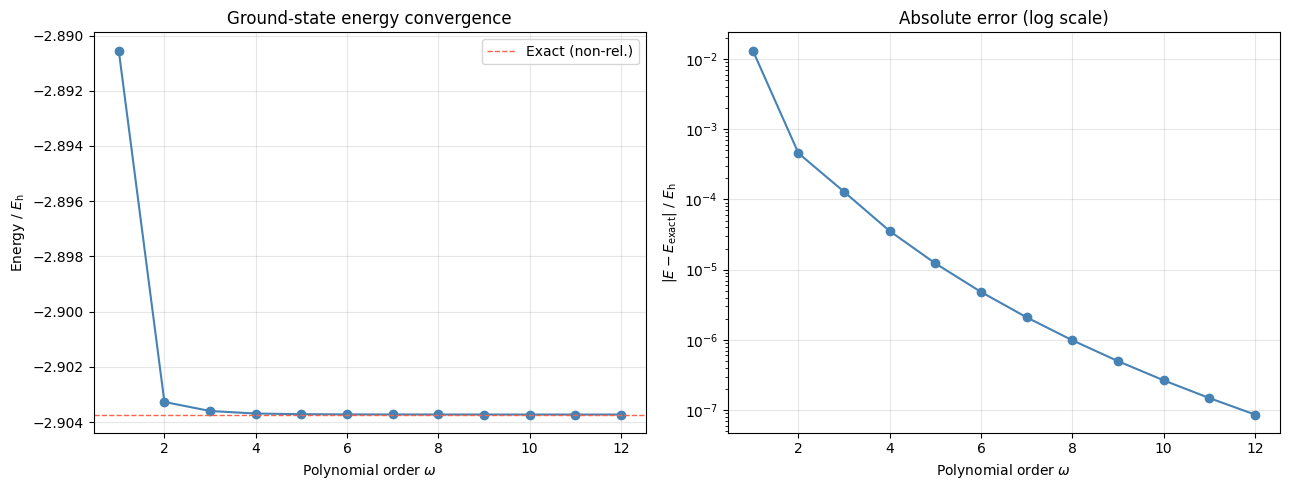

In [9]:
exact_energy = -2.903724377

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: absolute energy convergence
ax = axes[0]
ax.plot([r.omega for r in results], [r.energy_hartree for r in results],
        marker='o', color='steelblue', linewidth=1.5)
ax.axhline(exact_energy, color='tomato', linestyle='--', linewidth=1, label='Exact (non-rel.)')
ax.set_xlabel(r'Polynomial order $\omega$')
ax.set_ylabel('Energy / $E_\\mathrm{h}$')
ax.set_title('Ground-state energy convergence')
ax.legend()
ax.grid(alpha=0.3)

# Right panel: error on a log scale
ax2 = axes[1]
errors = [abs(r.energy_hartree - exact_energy) for r in results]
ax2.semilogy([r.omega for r in results], errors,
             marker='o', color='steelblue', linewidth=1.5)
ax2.set_xlabel(r'Polynomial order $\omega$')
ax2.set_ylabel(r'$|E - E_\mathrm{exact}|$ / $E_\mathrm{h}$')
ax2.set_title('Absolute error (log scale)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()